# Lab 3: Exercise 1

Let us consider the Laplace problem defined in the unit square $\Omega = {[0,1]}^2$: 
\begin{equation*}
  \begin{cases}
    -\Delta u = f, \qquad & \text{in }\Omega, \\
    u = 0, \qquad & \text{on }\partial\Omega.
  \end{cases}
\end{equation*}

1.   Write the **weak formulation** and the **Galerkin finite element discretization** of the problem;

2.   Compute the **load function $f$** such that
    $$
      u(x, y) = \sin{(\pi x)} \sin{(\pi y)},
    $$
    and verify that the previous exact solution vanishes at $\partial\Omega$.

3.   Solve the problem with **FEniCS** using the space $\mathbb{P}^k$ of continuous piecewise polynomials with degree at most $k$;

4.   Verify numerically the convergence rates in the norms $L^2$ and $H^1$ for $k=1$ and $k=2$.



### Weak formulation

As usual, in order to derive the weak formulation of the previous differential problem, we multiply the equation by a test function $v$ and we integrate over the domain $\Omega$ obtaining
$$
  -\int_\Omega \Delta u v \, d\boldsymbol{x} = \int_\Omega f v \, d\boldsymbol{x}.
$$
Integrating by parts the first term, from the previous relation we get:
$$
  - \int_{\partial\Omega} v (\boldsymbol{\nabla} u \cdot\boldsymbol{n}) \, d\sigma +
  \int_\Omega \boldsymbol{\nabla}u \cdot \boldsymbol{\nabla} v \, d\boldsymbol{x} =
  \int_\Omega f v \, d\boldsymbol{x}.
$$
Since the value of $u$ is contrained along $\partial\Omega$ we assume take $v$ such that $v_{|\partial\Omega}= 0$, so that the weak formulation reads:
$$
  \text{find } u \in H^1_0(\Omega) \text{ verifying }
  \int_\Omega \boldsymbol{\nabla}u \cdot \boldsymbol{\nabla} v \, d\boldsymbol{x} =
  \int_\Omega f v \, d\boldsymbol{x}, \qquad
  \forall v \in H^1_0(\Omega).
$$

### Galerkin approximation

If $V_h$ is a finite dimensional subspace of $H^1_0(\Omega)$ then the Galerkin
approximation of the problem reads:
\begin{equation*}
  \text{find } u_h \in  V_h \text{ such that }
  \int_\Omega \boldsymbol{\nabla}u_h \cdot \boldsymbol{\nabla} v_h \, d\boldsymbol{x} =
  \int_\Omega f v_h \, d\boldsymbol{x}, \quad
  \forall v_h \in V_h.
\end{equation*}

## Numerical solution with FEniCS

We start by installing and importing FEniCS:

In [0]:
## to suppress the output we can add the command %%capture
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *

In [0]:
from fenics import *
import matplotlib.pyplot as plt
import numpy as np

There are different built-in function in FEniCS to generate the 2D mesh. For a complete list see:
 https://fenicsproject.org/docs/dolfin/1.4.0/python/demo/documented/built-in_meshes/python/documentation.html 

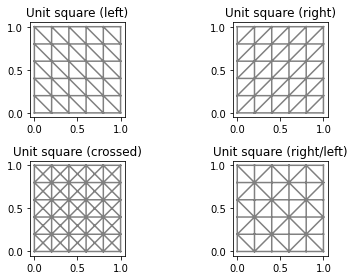

In [19]:
# different 2D (isotropic) mesh types 

mesh = UnitSquareMesh(5, 5, "left")
plt.subplot(2,2,1)
plot(mesh, title="Unit square (left)")

mesh = UnitSquareMesh(5, 5, "right")
plt.subplot(2,2,2)
plot(mesh, title="Unit square (right)")

mesh = UnitSquareMesh(5, 5, "crossed")
plt.subplot(2,2,3)
plot(mesh, title="Unit square (crossed)")

mesh = UnitSquareMesh(5, 5, "right/left")
plt.subplot(2,2,4)
plot(mesh, title="Unit square (right/left)")

plt.tight_layout()
plt.show()

We follow the FEniCS variational approach to design the finite element discretization of the 2D Laplace problem and find the discrete solution:

In [0]:
# 1. mesh generation
nx, ny = 10, 10
mesh = UnitSquareMesh(nx, ny, 'crossed')

In [0]:
# 2. definition of finite element space and boundary conditions
degree = 1
V = FunctionSpace(mesh, 'CG', degree)

g_boundary = Constant(0.0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, g_boundary, boundary)

# 3. assembling matrices and vectors
u = TrialFunction(V)
v = TestFunction(V)

a = dot(grad(u), grad(v)) * dx

# as a first example we consider a constant load function 
f = Constant(1.0)
L = f * v * dx

# 4. solve the discrete problem
u = Function(V)
solve(a == L, u, bc)

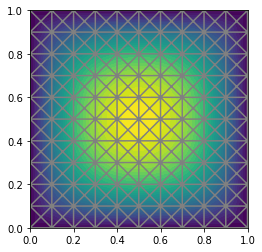

In [34]:
# 5. postprocess

# to export the solution for visualisation in paraview
vtkfile = File('ex01.pvd')
vtkfile << u

# to plot the results within FEniCS
plot(u)
plot(mesh)
plt.show()

## Convergence analysis

In what follows we assess the covergence performance of the FEM approximation of the Laplace problem above considering, as exact solutin, the function $u(x, y) = \sin{(\pi x)} \sin{(\pi y)}$. We consider the lagrangian $\mathbb{P}^k$ elements, with $k=1,2$ and measure the error in the  $L^2$ and $H^1$ norms.

### Analytic solution

Given $u$ solution of the problem it is enough to check if the boundary
condition is satisfied (trivial) and the function $f$ is given by:
\begin{equation*}
  f = -\Delta u = -\left(
    \frac{\partial^2 u}{{\partial x}^2}
    +
    \frac{\partial^2 u}{{\partial y}^2}
  \right) =
  2 \pi^2 \sin{(\pi x)} \sin{(\pi y)}.
\end{equation*}

### FEniCS 2D Laplacian solver

As we have done for the 1D Laplace problem, we define a 2D Laplacian solver function taking three arguments: the meshsize ($h \sim \frac{1}n$), the polynomial degree $k$, and the load function $f$: 

In [0]:
def solve_laplace(n, degree, f):
    # 1. mesh generation
    nx, ny = n, n
    mesh = UnitSquareMesh(nx, ny, 'crossed')

    # 2. definition of finite element space
    V = FunctionSpace(mesh, 'CG', degree)

    g_boundary = Constant(0.0)

    def boundary(x, on_boundary):
        return on_boundary

    bc = DirichletBC(V, g_boundary, boundary)

    # 3/4. assembling matrices and vectors/solve
    u = TrialFunction(V)
    v = TestFunction(V)

    a = dot(grad(u), grad(v)) * dx

    L = f * v * dx

    u = Function(V)
    solve(a == L, u, bc)

    return u

For each polynomial degree, we consider four nested refinements of the initial "crossed" triangular mesh. For each mesh we compute the corresponding errors. 

In [74]:
M_err=np.zeros((4,5))

for degree in [1, 2]:
    f = Expression('2*pi*pi * sin(pi*x[0]) * sin(pi*x[1])', degree=degree+1)
    u = Expression('sin(pi*x[0]) * sin(pi*x[1])', degree=degree+2)

    for i in range(5):
        n = 10*(2**i)
        uh = solve_laplace(n, degree, f)
        eL2 = errornorm(u, uh, 'L2')
        eH1 = errornorm(u, uh, 'H10')

        j= 2*(degree-1)
        M_err[j,i] = eL2 
        M_err[j+1,i] = eH1

        print('n={} degree={} eL2={:.2e} eH1={:.2e}'.format(n, degree, eL2, eH1));

    print()

#print(M_err)

n=10 degree=1 eL2=3.87e-03 eH1=1.84e-01
n=20 degree=1 eL2=9.67e-04 eH1=9.19e-02
n=40 degree=1 eL2=2.42e-04 eH1=4.60e-02
n=80 degree=1 eL2=6.04e-05 eH1=2.30e-02
n=160 degree=1 eL2=1.51e-05 eH1=1.15e-02

n=10 degree=2 eL2=8.45e-05 eH1=7.51e-03
n=20 degree=2 eL2=1.06e-05 eH1=1.88e-03
n=40 degree=2 eL2=1.33e-06 eH1=4.71e-04
n=80 degree=2 eL2=1.66e-07 eH1=1.18e-04
n=160 degree=2 eL2=2.08e-08 eH1=2.94e-05



### Visualisation of the convergence results

The convergence order of the method with respect to the meshsize $h$ is defined as the exponent $\alpha$ such that $ e_h \sim h^\alpha$. Hence to numerically evaluate $\alpha$ we can plot the error with respect to the meshsize in logaritmic scale.

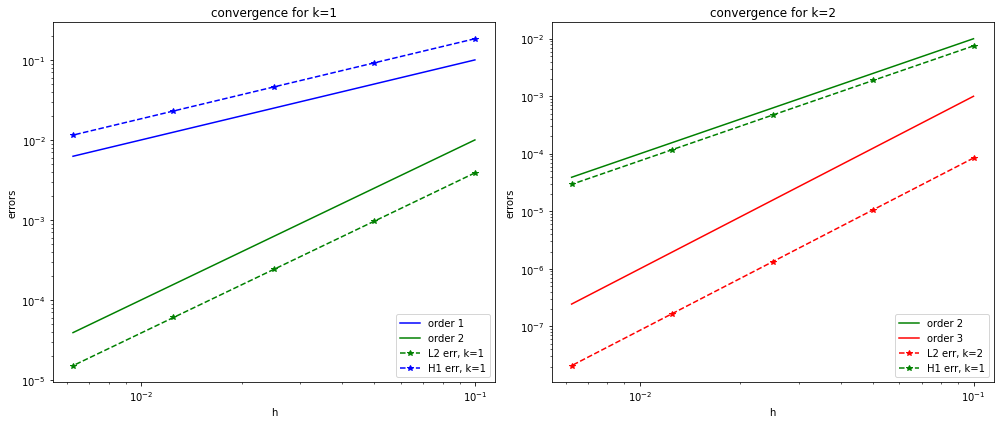

In [75]:
# definition of the meshsize 
h = np.array([1.0/(10*(2**i)) for i in range(5)])

# we use the subplots axis layout managers in matplotlib
fig, axes = plt.subplots(1,2, figsize=(14,6))

axes[0].loglog(h, h, 'b',label="order 1")
axes[0].loglog(h, h**2, 'g',label="order 2")

axes[0].loglog(h, M_err[0,:], 'g--*',label="L2 err, k=1")
axes[0].loglog(h, M_err[1,:], 'b--*',label="H1 err, k=1")

axes[0].set_title("convergence for k=1");
axes[0].set_xlabel("h")
axes[0].set_ylabel("errors")
axes[0].legend(loc=4)

axes[1].loglog(h, h**2, 'g',label="order 2")
axes[1].loglog(h, h**3, 'r', label="order 3")

axes[1].loglog(h, M_err[2,:], 'r--*',label="L2 err, k=2")
axes[1].loglog(h, M_err[3,:], 'g--*',label="H1 err, k=1")

axes[1].set_title("convergence for k=2");
axes[1].set_xlabel("h")
axes[1].set_ylabel("errors")
axes[1].legend(loc=4)

fig.tight_layout()
plt.show()

# to export 
fig.savefig("convergence.png")